In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [18]:
data=pd.read_csv(r"C:\Users\C\Downloads\WA_Fn-UseC_-Telco-Customer-Churn (2).csv")

In [19]:
data.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [21]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: >

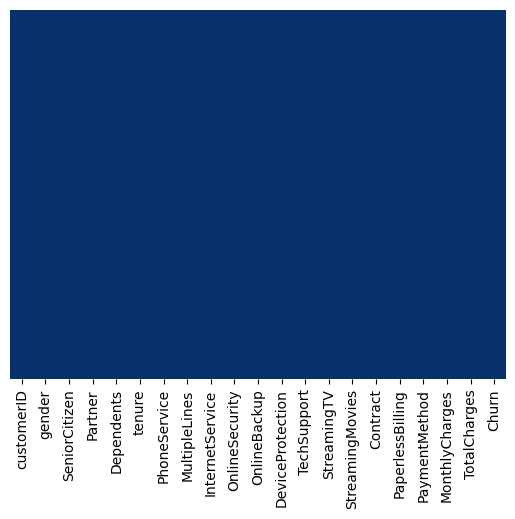

In [22]:
sns.heatmap(data.isnull(),yticklabels=False,cbar=False,cmap="Blues_r")

There are no missing values in the dataset

In [23]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'],errors='coerce')

In [24]:
nan_cols = [i for i in data.columns if data[i].isnull().any()]
nan_cols

['TotalCharges']

Although there are no missing values some values had the space in it as a value. hence when changing the format of the data is produces NAN values.

In [25]:
# there were ten null values after changing the data type of the TotalCharges variable. hence removed those points.
data.dropna(subset = ["TotalCharges"], inplace=True)

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [27]:
data.shape

(7032, 21)

In [28]:
# There are no duplicate rows in the dataset.
duplicateRows = data[data.duplicated()]
duplicateRows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [29]:
# The unnamed column was dropped since it was a index column and customer Id column also dropped since it is a unique value column.
data= data.drop(['customerID'], axis=1) 

Check For Categorical Variable labels

In [30]:
def cat_unique_col_values(df):
    for column in df:
        if df[column].dtypes=='object':
            print(f'{column}: {df[column].unique()}') 

In [31]:
cat_unique_col_values(data)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


Some of the columns have no internet service or no phone service, that can be replaced with a simple No

In [32]:
data.replace('No internet service','No',inplace=True)
data.replace('No phone service','No',inplace=True)

In [33]:
cat_unique_col_values(data)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


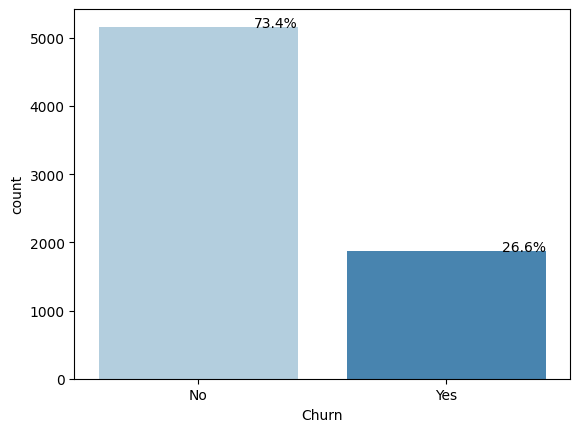

In [34]:
ax = sns.countplot(x="Churn", data=data, palette="Blues")
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/len(data))
    x = p.get_x() + p.get_width()
    y = p.get_height()
    ax.annotate(percentage, (x, y),ha='right')
plt.show()

Text(0.5, 1.0, 'percentage of Senior Citizens')

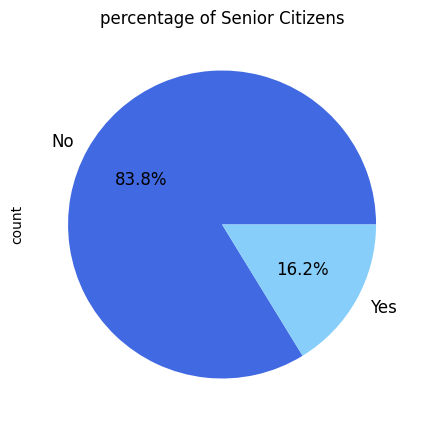

In [35]:
#Pie chart of percentages of senior citizens
import matplotlib.ticker as mtick
ax = (data['SeniorCitizen'].value_counts()*100.0 /len(data)).plot.pie(autopct='%.1f%%', labels = ['No', 'Yes'],figsize =(5,5),colors=['royalblue','lightskyblue'], fontsize = 12 )                                                                           
ax.set_title('percentage of Senior Citizens', fontsize = 12)

Text(0.5, 1.0, 'percentage of gender')

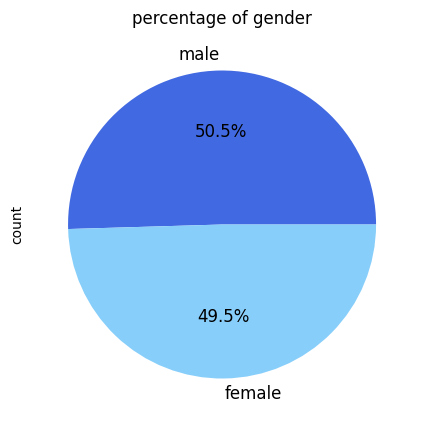

In [36]:
# pie chart of gender of customers
ax = (data['gender'].value_counts()*100.0 /len(data)).plot.pie(autopct='%.1f%%', labels = ['male', 'female'],figsize =(5,5),colors=['royalblue','lightskyblue'], fontsize = 12 )                                                                           
ax.set_title('percentage of gender', fontsize = 12)

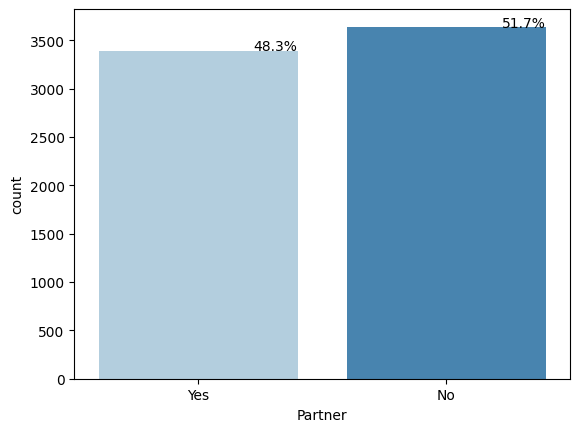

In [37]:
ax = sns.countplot(x="Partner", data=data, palette="Blues")
for p in ax.patches:
  percentage = '{:.1f}%'.format(100 * p.get_height()/len(data))
  x = p.get_x() + p.get_width()
  y = p.get_height()
  ax.annotate(percentage, (x, y),ha='right')
plt.show()

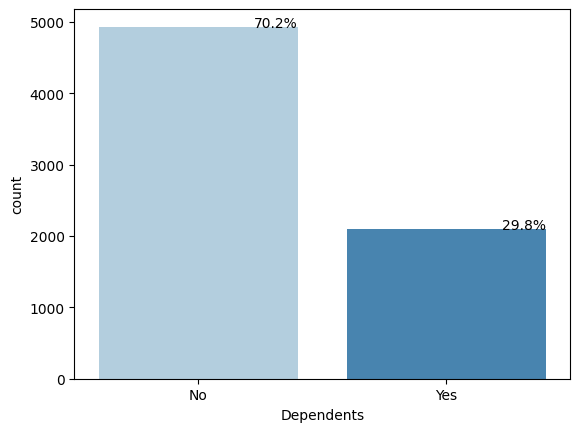

In [38]:
ax = sns.countplot(x="Dependents", data=data, palette="Blues")
for p in ax.patches:
  percentage = '{:.1f}%'.format(100 * p.get_height()/len(data))
  x = p.get_x() + p.get_width()
  y = p.get_height()
  ax.annotate(percentage, (x, y),ha='right')
plt.show()

Insights: There are only 16.2% senior citizens in the dataset.The gender have equal distribution in the dataset.Around 49% customers have partners.Around 30% customers have dependents

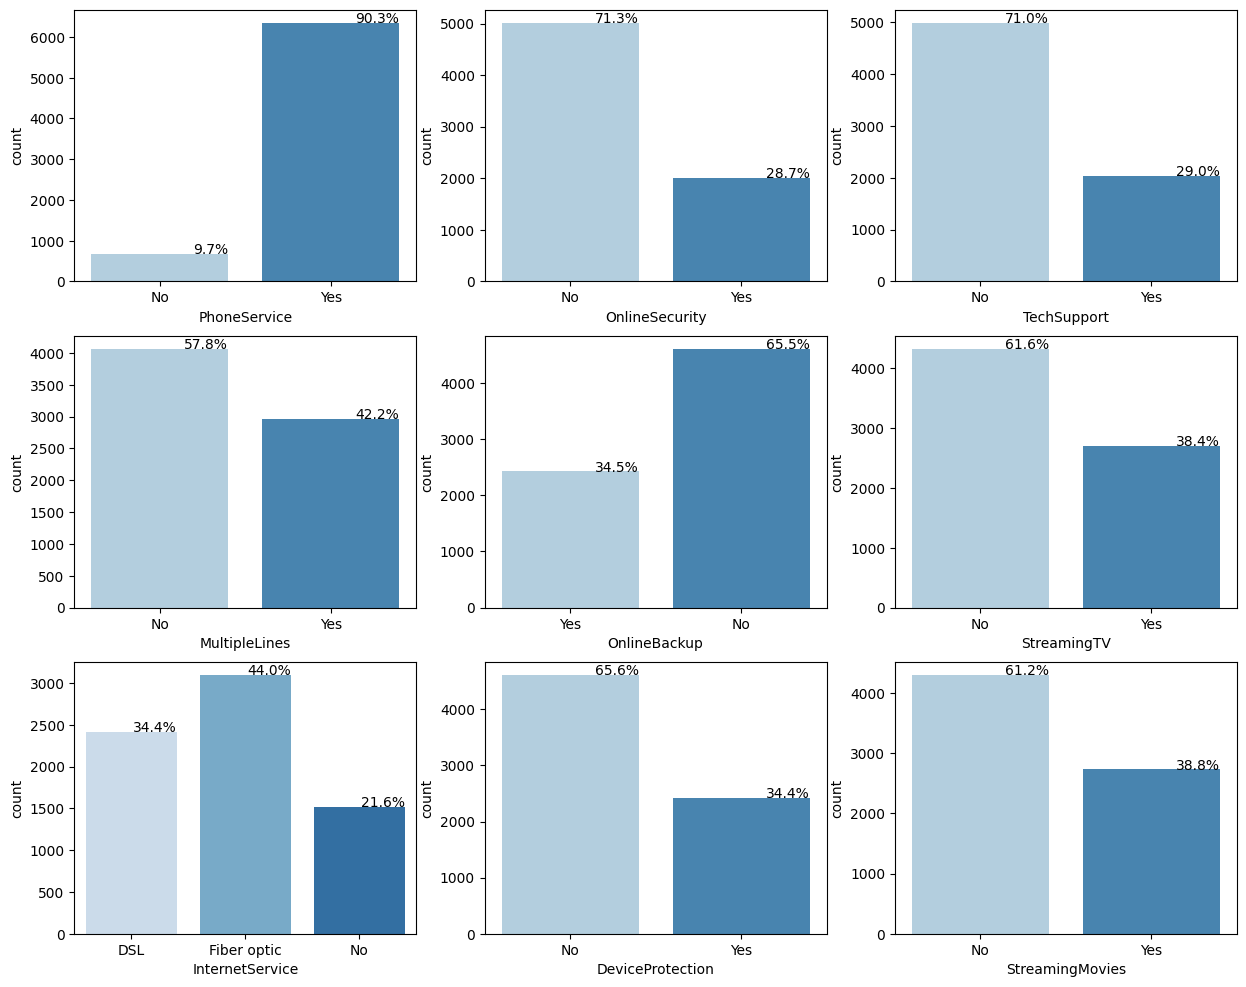

In [39]:
#These are the services provide by the company
services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

fig, axes = plt.subplots(nrows = 3,ncols = 3,figsize = (15,12))
for i, item in enumerate(services):
  if i < 3:
    ax = sns.countplot(x=data[item], data=data, palette="Blues",ax=axes[i,0])
    for p in ax.patches:
      percentage = '{:.1f}%'.format(100 * p.get_height()/len(data))
      x = p.get_x() + p.get_width()
      y = p.get_height()
      ax.annotate(percentage, (x, y),ha='right')        
  elif i >=3 and i < 6:
    ax = sns.countplot(x=data[item], data=data, palette="Blues",ax=axes[i-3,1])
    for p in ax.patches:
      percentage = '{:.1f}%'.format(100 * p.get_height()/len(data))
      x = p.get_x() + p.get_width()
      y = p.get_height()
      ax.annotate(percentage, (x, y),ha='right') 
  elif i < 9:
    ax = sns.countplot(x=data[item], data=data, palette="Blues",ax=axes[i-6,2])
    for p in ax.patches:
      percentage = '{:.1f}%'.format(100 * p.get_height()/len(data))
      x = p.get_x() + p.get_width()
      y = p.get_height()
      ax.annotate(percentage, (x, y),ha='right') 

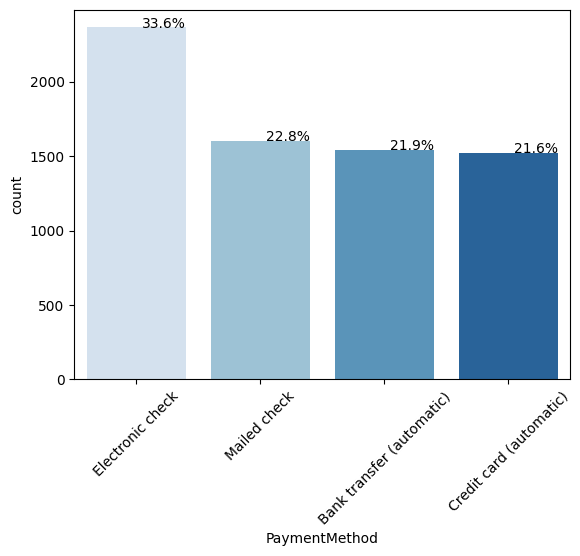

In [40]:
ax = sns.countplot(x="PaymentMethod", data=data, palette="Blues")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

for p in ax.patches:
  percentage = '{:.1f}%'.format(100 * p.get_height()/len(data))
  x = p.get_x() + p.get_width()
  y = p.get_height()
  ax.annotate(percentage, (x, y),ha='right') 

Tenure is the number of months the customer has stayed with the company

C:\Users\C\AppData\Local\Temp\ipykernel_11280\1014129125.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(data['tenure'], hist=True, kde=False, bins=int(180/5), color = 'royalblue', hist_kws={'edgecolor':'black'}, kde_kws={'linewidth': 4})


Text(0.5, 1.0, 'no of Customers by their tenure')

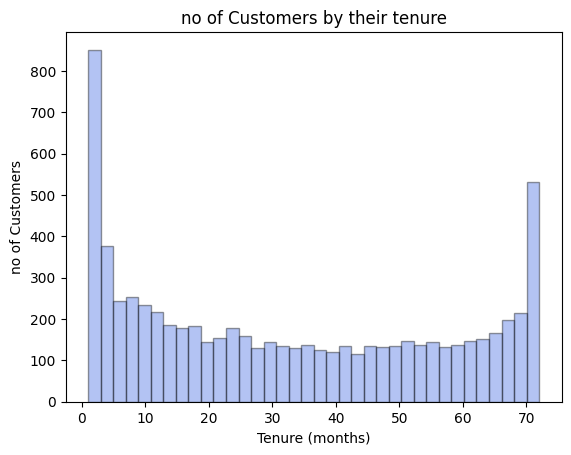

In [41]:
import warnings
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning) 
ax = sns.distplot(data['tenure'], hist=True, kde=False, bins=int(180/5), color = 'royalblue', hist_kws={'edgecolor':'black'}, kde_kws={'linewidth': 4})
ax.set_ylabel('no of Customers')
ax.set_xlabel('Tenure (months)')
ax.set_title('no of Customers by their tenure')

After looking at the above histogram we can see that a lot of customers have been with the telecom company for just a month, while quite a many are there for about 72 months. This could be potentially because different customers have different contracts. Thus based on the contract they are into it could be more/less easier for the customers to stay/leave the company.

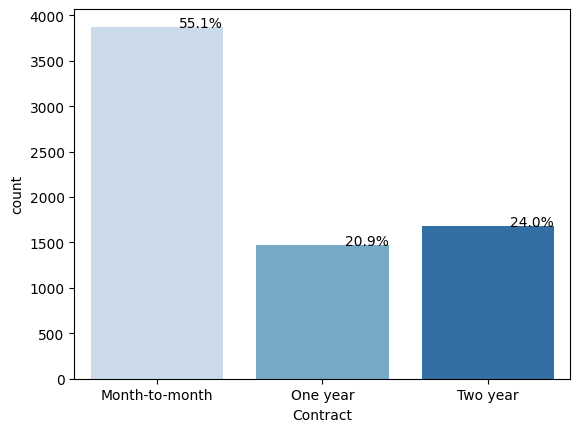

In [42]:
ax = sns.countplot(x="Contract", data=data, palette="Blues")
for p in ax.patches:
  percentage = '{:.1f}%'.format(100 * p.get_height()/len(data))
  x = p.get_x() + p.get_width()
  y = p.get_height()
  ax.annotate(percentage, (x, y),ha='right') 

55% of customers are month to month contract type and most of them have been churned. That is the reason for many customers have low tenure.

C:\Users\C\AppData\Local\Temp\ipykernel_11280\1582994507.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(data[data['Contract']=='Month-to-month']['tenure'],
C:\Users\C\AppData\Local\Temp\ipykernel_11280\1582994507.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(data[data['Cont

Text(0.5, 1.0, 'Two Year Contract')

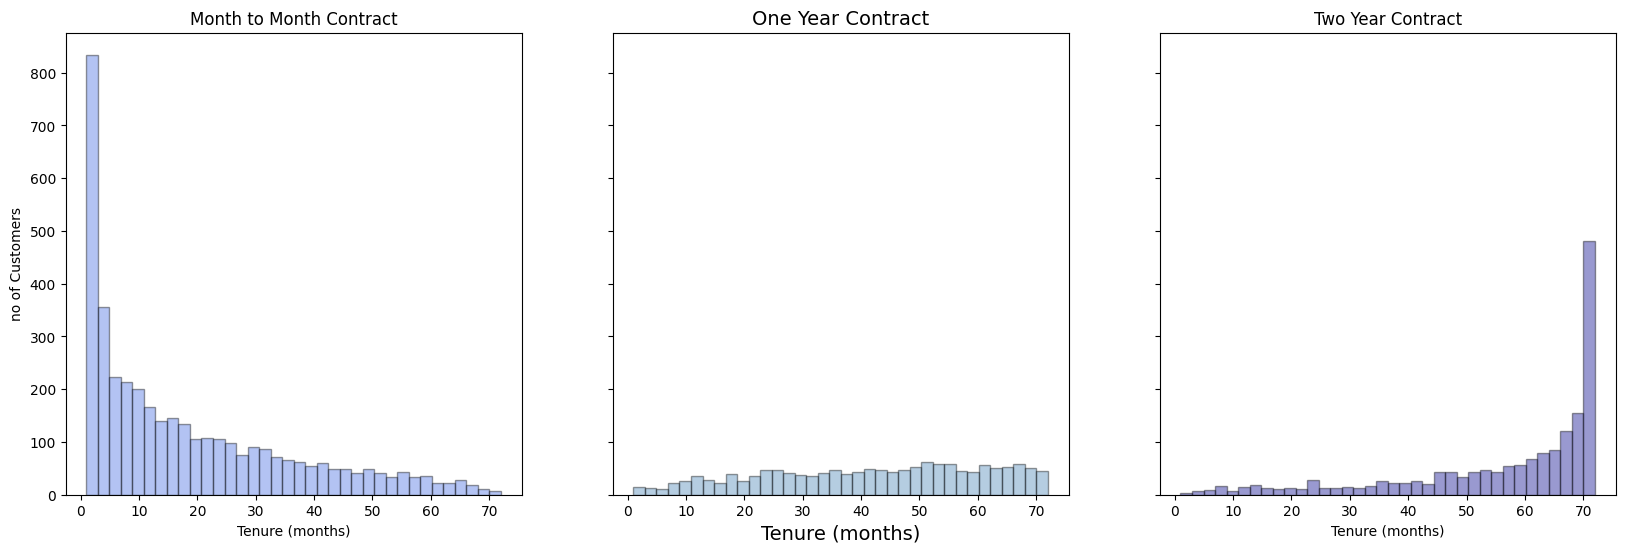

In [43]:
fig, (ax1,ax2,ax3) = plt.subplots(nrows=1, ncols=3, sharey = True, figsize = (20,6))

ax = sns.distplot(data[data['Contract']=='Month-to-month']['tenure'],
                   hist=True, kde=False,
                   bins=int(180/5), color = 'royalblue',
                   hist_kws={'edgecolor':'black'},
                   kde_kws={'linewidth': 4},
                 ax=ax1)
ax.set_ylabel('no of Customers')
ax.set_xlabel('Tenure (months)')
ax.set_title('Month to Month Contract')

ax = sns.distplot(data[data['Contract']=='One year']['tenure'],
                   hist=True, kde=False,
                   bins=int(180/5), color = 'steelblue',
                   hist_kws={'edgecolor':'black'},
                   kde_kws={'linewidth': 4},
                 ax=ax2)
ax.set_xlabel('Tenure (months)',size = 14)
ax.set_title('One Year Contract',size = 14)

ax = sns.distplot(data[data['Contract']=='Two year']['tenure'],
                   hist=True, kde=False,
                   bins=int(180/5), color = 'darkblue',
                   hist_kws={'edgecolor':'black'},
                   kde_kws={'linewidth': 4},
                 ax=ax3)

ax.set_xlabel('Tenure (months)')
ax.set_title('Two Year Contract')

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

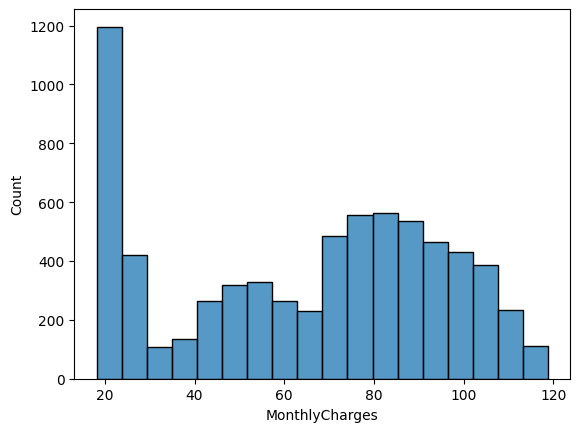

In [44]:
sns.histplot(data=data, x="MonthlyCharges")

<Axes: xlabel='TotalCharges', ylabel='Count'>

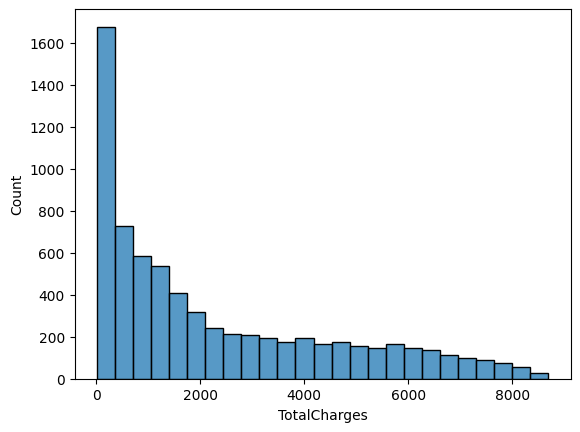

In [45]:
sns.histplot(data=data, x="TotalCharges")

most of the customers have low monthly charges which cause for low total charges.

<Axes: xlabel='TotalCharges'>

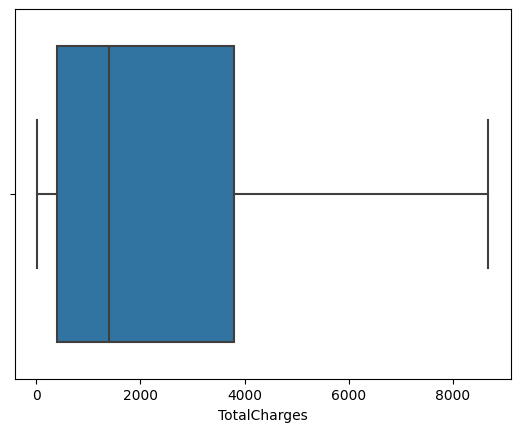

In [46]:
sns.boxplot(x=data['TotalCharges'])

<Axes: xlabel='MonthlyCharges'>

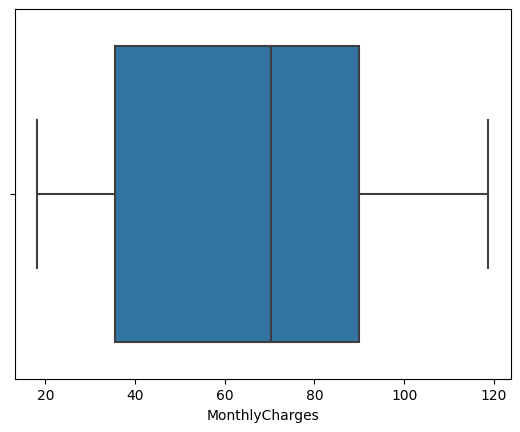

In [47]:
sns.boxplot(x=data['MonthlyCharges'])

<Axes: xlabel='tenure'>

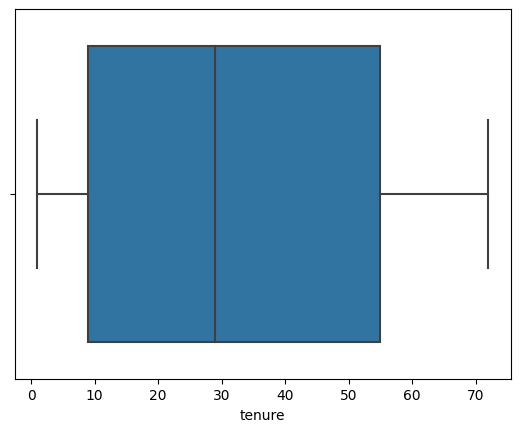

In [48]:
sns.boxplot(x=data['tenure'])

There are no outliers in the dataset as we can see from the boxplots.

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

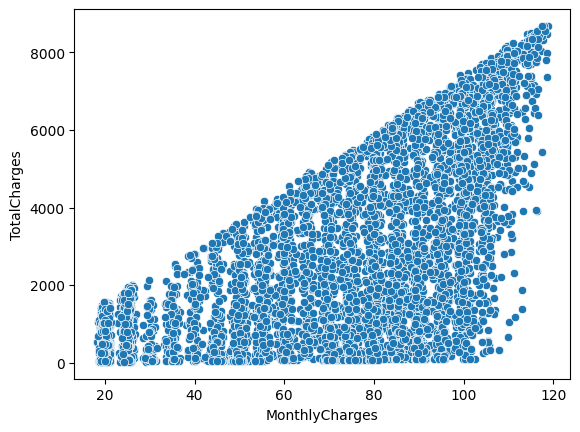

In [49]:
sns.scatterplot(data=data, x="MonthlyCharges", y="TotalCharges")

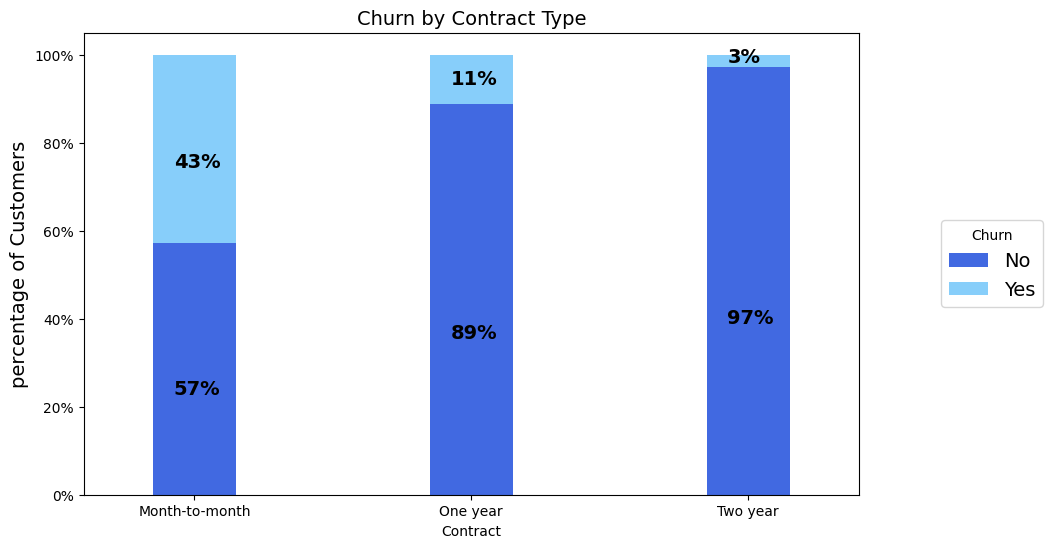

In [50]:
colors = ['royalblue','lightskyblue']
contract_churn = data.groupby(['Contract','Churn']).size().unstack()

ax = (contract_churn.T*100.0 / contract_churn.T.sum()).T.plot(kind='bar',width = 0.3,stacked = True,rot = 0, figsize = (10,6),color = colors)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='center right',prop={'size':14},title = 'Churn', bbox_to_anchor=(1.25, 0.5))
ax.set_ylabel('percentage of Customers',size = 14)
ax.set_title('Churn by Contract Type',size = 14)

# Code to add the data labels on the stacked bar chart
for p in ax.patches:
  width, height = p.get_width(), p.get_height()
  x, y = p.get_xy() 
  ax.annotate('{:.0f}%'.format(height), (p.get_x()+.25*width, p.get_y()+.4*height),color = 'black',weight = 'bold',size = 14)

43% of month to month contract customers have churned in this company. while only 3% of customers have churned in two year contract type.

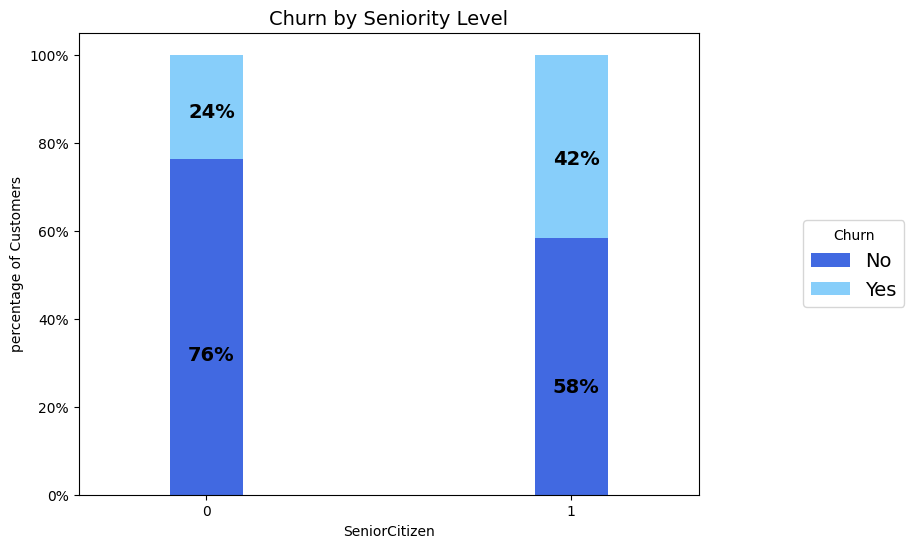

In [51]:
seniority_churn = data.groupby(['SeniorCitizen','Churn']).size().unstack()

ax = (seniority_churn.T*100.0 / seniority_churn.T.sum()).T.plot(kind='bar', width = 0.2, stacked = True, rot = 0,  figsize = (8,6), color = colors)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='center',prop={'size':14},title = 'Churn',bbox_to_anchor=(1.25, 0.5))
ax.set_ylabel('percentage of Customers')
ax.set_title('Churn by Seniority Level',size = 14)

# add the data labels on the stacked bar chart
for p in ax.patches:
  width, height = p.get_width(), p.get_height()
  x, y = p.get_xy() 
  ax.annotate('{:.0f}%'.format(height), (p.get_x()+.25*width, p.get_y()+.4*height),color = 'black',weight = 'bold',size =14)

42% of senior citizens have churned while only 24% of non senior citizens have churned.

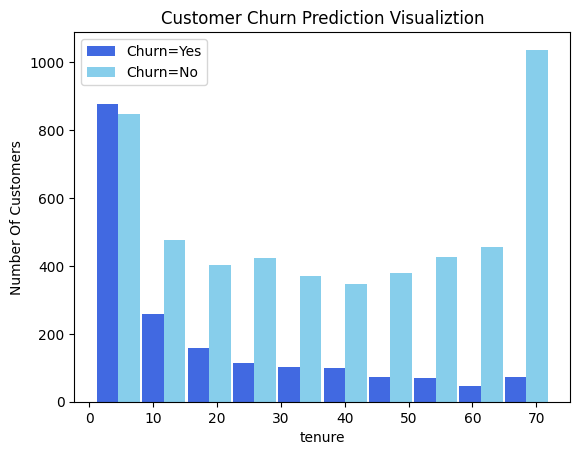

In [52]:
import warnings
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning) 
tenure_churn_no = data[data.Churn=='No'].tenure
tenure_churn_yes = data[data.Churn=='Yes'].tenure

plt.xlabel("tenure")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")

plt.hist([tenure_churn_yes, tenure_churn_no], rwidth=0.95, color=['royalblue','skyblue'],label=['Churn=Yes','Churn=No'])
plt.legend()

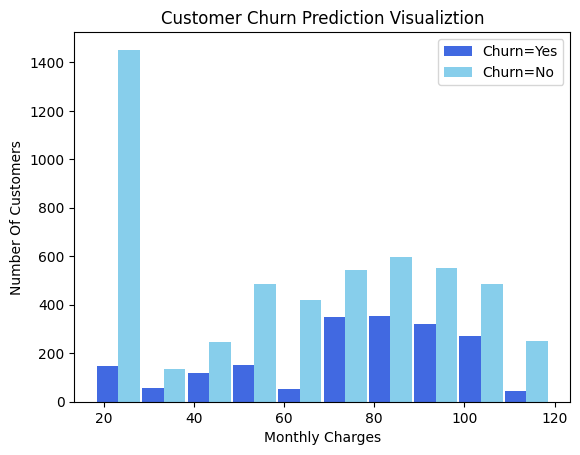

In [53]:
mc_churn_no = data[data.Churn=='No'].MonthlyCharges      
mc_churn_yes = data[data.Churn=='Yes'].MonthlyCharges      

plt.xlabel("Monthly Charges")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")

plt.hist([mc_churn_yes, mc_churn_no], rwidth=0.95, color=['royalblue','skyblue'],label=['Churn=Yes','Churn=No'])
plt.legend()

C:\Users\C\AppData\Local\Temp\ipykernel_11280\2426663924.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(data.MonthlyCharges[(data["Churn"] == 'No') ], color="royalblue", shade = True)
C:\Users\C\AppData\Local\Temp\ipykernel_11280\2426663924.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(data.MonthlyCharges[(data["Churn"] == 'Yes') ], ax =ax, color="Blue", shade= True)


Text(0.5, 1.0, 'Distribution of monthly charges by churn')

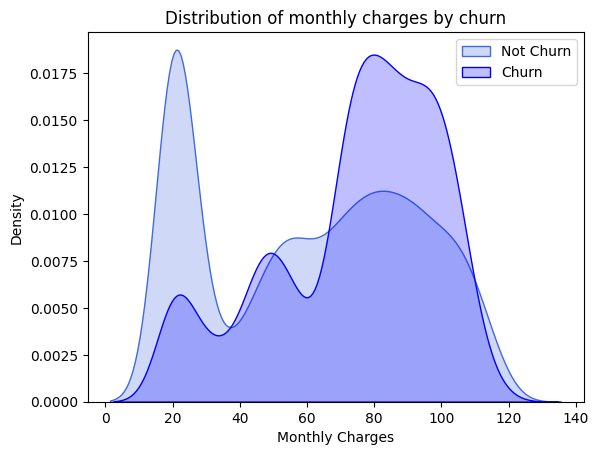

In [54]:
ax = sns.kdeplot(data.MonthlyCharges[(data["Churn"] == 'No') ], color="royalblue", shade = True)
ax = sns.kdeplot(data.MonthlyCharges[(data["Churn"] == 'Yes') ], ax =ax, color="Blue", shade= True)
ax.legend(["Not Churn","Churn"],loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Monthly Charges')
ax.set_title('Distribution of monthly charges by churn')

In [55]:
# dataset with monthly charges in between 70-110
mc_high_churn_prob = data[(data['MonthlyCharges']>70)& (data['MonthlyCharges']<110)]

In [56]:
# the customers with monthly charges in between 70-110 and churn=yes
churn_data=mc_high_churn_prob[mc_high_churn_prob['Churn']=='Yes']

In [57]:
churn_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
13,Male,0,No,No,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes
26,Male,0,Yes,Yes,47,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes


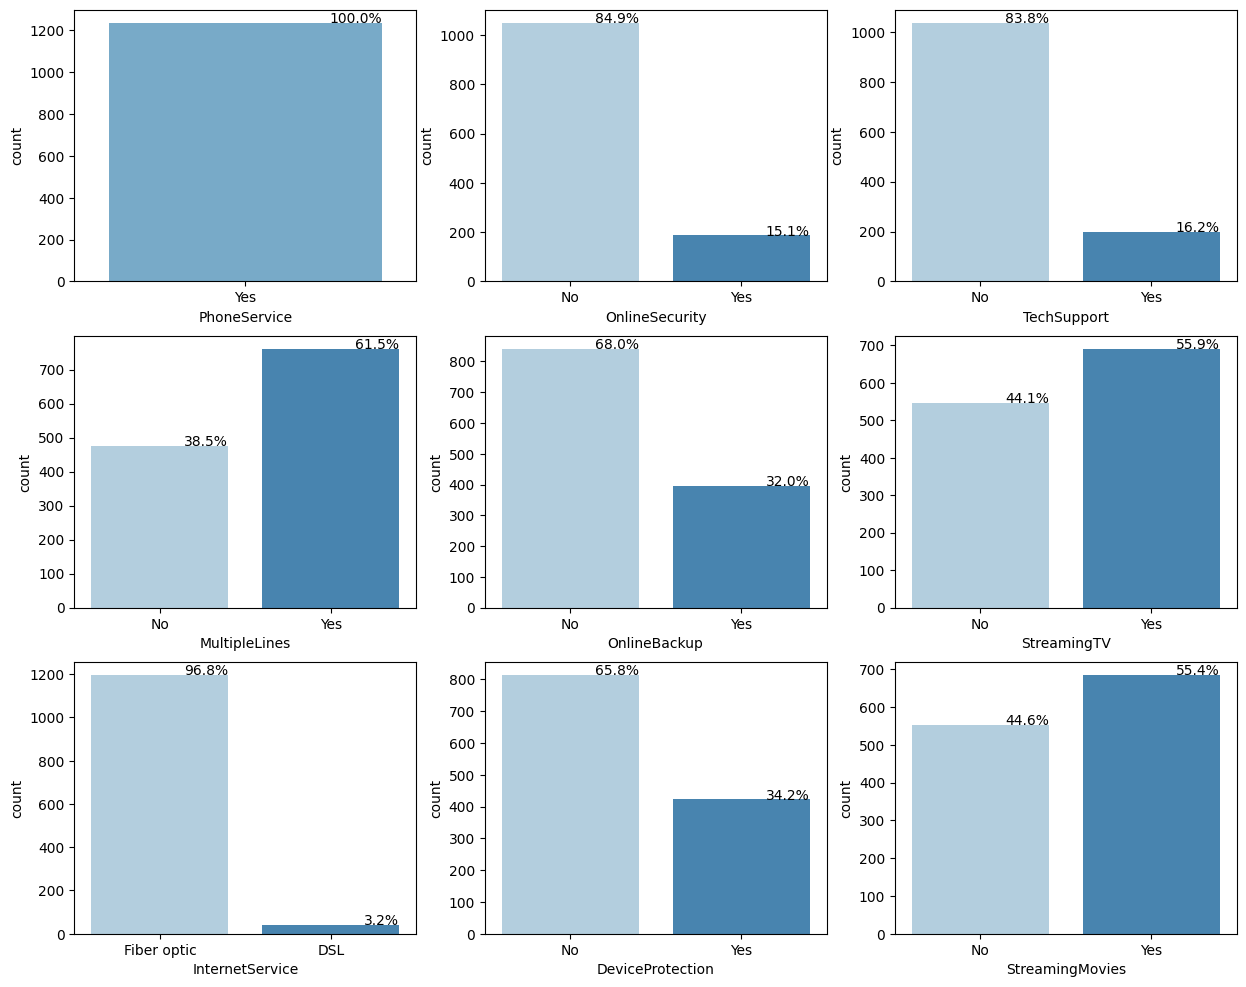

In [58]:
fig, axes = plt.subplots(nrows = 3,ncols = 3,figsize = (15,12))
for i, item in enumerate(services):
  if i < 3:
    ax = sns.countplot(x=churn_data[item], data=churn_data, palette="Blues",ax=axes[i,0])
    for p in ax.patches:
      percentage = '{:.1f}%'.format(100 * p.get_height()/len(churn_data))
      x = p.get_x() + p.get_width()
      y = p.get_height()
      ax.annotate(percentage, (x, y),ha='right')        
  elif i >=3 and i < 6:
    ax = sns.countplot(x=churn_data[item], data=churn_data, palette="Blues",ax=axes[i-3,1])
    for p in ax.patches:
      percentage = '{:.1f}%'.format(100 * p.get_height()/len(churn_data))
      x = p.get_x() + p.get_width()
      y = p.get_height()
      ax.annotate(percentage, (x, y),ha='right') 
  elif i < 9:
    ax = sns.countplot(x=churn_data[item], data=churn_data, palette="Blues",ax=axes[i-6,2])
    for p in ax.patches:
      percentage = '{:.1f}%'.format(100 * p.get_height()/len(churn_data))
      x = p.get_x() + p.get_width()
      y = p.get_height()
      ax.annotate(percentage, (x, y),ha='right')

The customers who have higher chance of churn with high monthly charges, more than 60% do not have online security, tech support, multiple lines, online backup and device protection.

In the range of 70-110 of monthly charged customers have higher chance of churning. So the packages for those ranges could be improved.

C:\Users\C\AppData\Local\Temp\ipykernel_11280\1405814212.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(data.TotalCharges[(data["Churn"] == 'No') ], color="royalblue", shade = True)
C:\Users\C\AppData\Local\Temp\ipykernel_11280\1405814212.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(data.TotalCharges[(data["Churn"] == 'Yes') ], ax =ax, color="Blue", shade= True)


Text(0.5, 1.0, 'Distribution of total charges by churn')

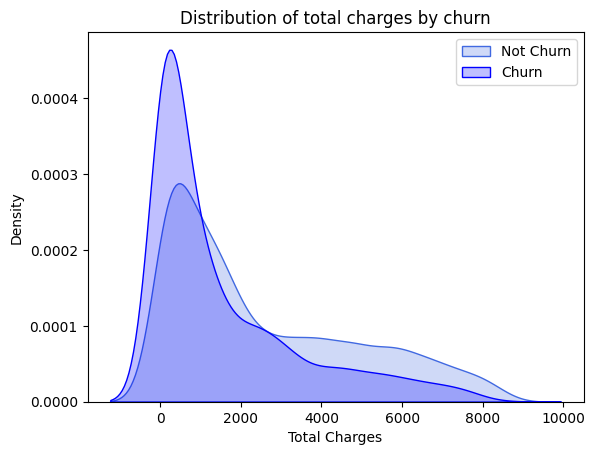

In [59]:
ax = sns.kdeplot(data.TotalCharges[(data["Churn"] == 'No') ], color="royalblue", shade = True)
ax = sns.kdeplot(data.TotalCharges[(data["Churn"] == 'Yes') ], ax =ax, color="Blue", shade= True)
ax.legend(["Not Churn","Churn"],loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Total Charges')
ax.set_title('Distribution of total charges by churn')

In [60]:
data.shape

(7032, 20)

categorical_cols= data.select_dtypes(include=['object'])

print(f'The dataset contains {len(categorical_cols.columns.tolist())} categorical columns')

In [61]:
categorical_cols= data.select_dtypes(include=['object'])

print(f'The dataset contains {len(categorical_cols.columns.tolist())} categorical columns')

The dataset contains 16 categorical columns


In [62]:
categorical_cols.describe()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,2,2,2,2,2,3,2,2,2,2,2,2,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3549,3639,4933,6352,4065,3096,5017,4607,4614,4992,4329,4301,3875,4168,2365,5163


In [63]:
for cols in categorical_cols.columns:
  print(cols,':', len(categorical_cols[cols].unique()),'labels')

gender : 2 labels
Partner : 2 labels
Dependents : 2 labels
PhoneService : 2 labels
MultipleLines : 2 labels
InternetService : 3 labels
OnlineSecurity : 2 labels
OnlineBackup : 2 labels
DeviceProtection : 2 labels
TechSupport : 2 labels
StreamingTV : 2 labels
StreamingMovies : 2 labels
Contract : 3 labels
PaperlessBilling : 2 labels
PaymentMethod : 4 labels
Churn : 2 labels


Dython library was used to measure correlations among variables.

In [64]:
!pip install dython


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\C\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [65]:
!{sys.executable} -m pip install dython

'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


In [66]:
from dython.nominal import associations

In [67]:
!pip show dython

Name: dython
Version: 0.7.3
Summary: A set of data tools in Python
Home-page: http://shakedzy.xyz/dython
Author: Shaked Zychlinski
Author-email: shakedzy@gmail.com
License: MIT
Location: C:\Users\C\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages
Requires: matplotlib, numpy, pandas, psutil, scikit-learn, scikit-plot, scipy, seaborn
Required-by: 


In [68]:
!{__import__('sys').executable} -m pip install "dython==0.7.3"


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\C\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


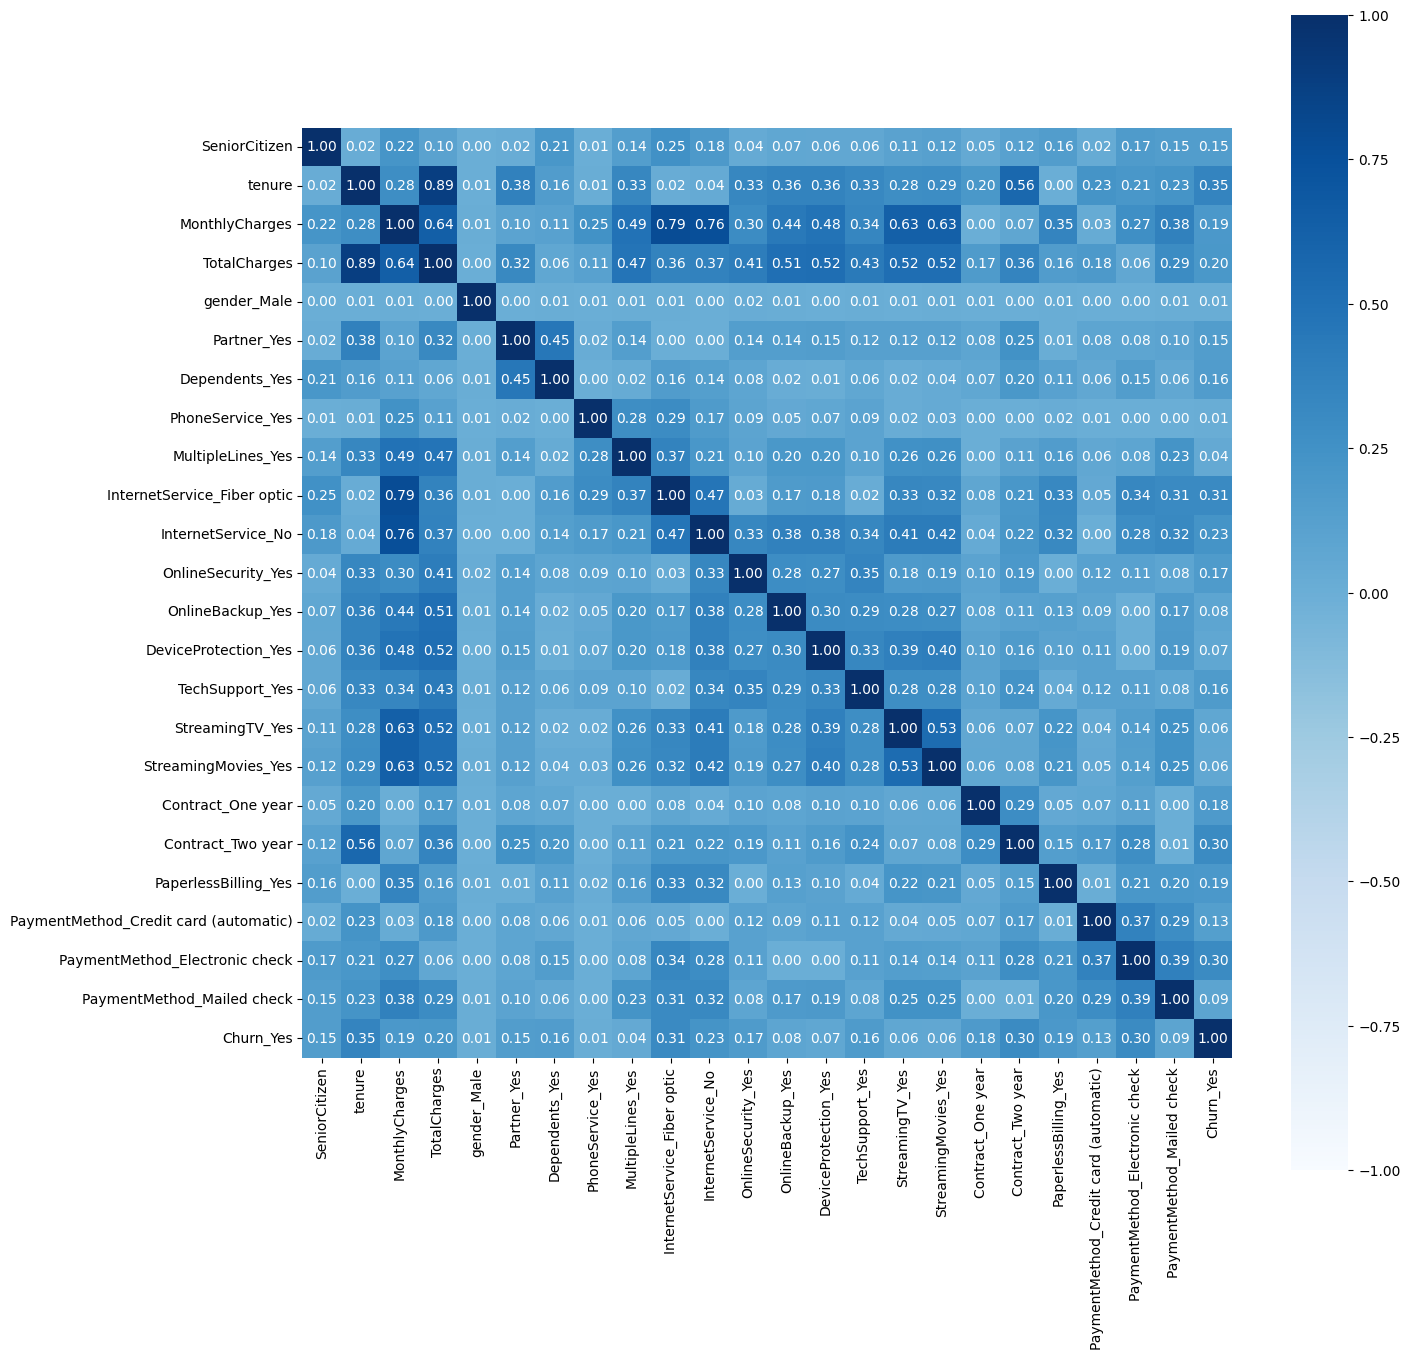

{'corr':                                        SeniorCitizen    tenure  \
 SeniorCitizen                               1.000000  0.015683   
 tenure                                      0.015683  1.000000   
 MonthlyCharges                              0.219874  0.275339   
 TotalCharges                                0.102411  0.889177   
 gender_Male                                 0.001434  0.005285   
 Partner_Yes                                 0.016571  0.381912   
 Dependents_Yes                              0.210129  0.163386   
 PhoneService_Yes                            0.007739  0.007877   
 MultipleLines_Yes                           0.142606  0.332399   
 InternetService_Fiber optic                 0.254535  0.017930   
 InternetService_No                          0.182051  0.037529   
 OnlineSecurity_Yes                          0.038150  0.328297   
 OnlineBackup_Yes                            0.066257  0.361138   
 DeviceProtection_Yes                        0.059108 

In [76]:
from dython.nominal import associations
associations(data,numerical_columns=['tenure','MonthlyCharges','TotalCharges'] ,nom_nom_assoc='cramer',num_num_assoc='spearman',cramers_v_bias_correction=False,
             hide_columns='customerID',hide_rows='customerID',figsize=(15, 15),cmap="Blues")

In [77]:
#creating dummy variables for categorical variables here drop_first determines whether to get k-1 dummies out of k categorical levels by removing the first level.
data = pd.get_dummies(data, drop_first=True)

In [78]:
data.shape

(7032, 24)

In [79]:
data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,True,...,False,False,False,False,False,True,False,True,False,True


In [80]:
# scaling numerical features since the ranges are different
cols_to_scale = ['tenure','MonthlyCharges','TotalCharges']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

In [81]:
data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,0.000000,0.115423,0.001275,False,True,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,0.464789,0.385075,0.215867,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,0.014085,0.354229,0.010310,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,0.619718,0.239303,0.210241,True,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
4,0,0.014085,0.521891,0.015330,False,False,False,True,False,True,...,False,False,False,False,False,True,False,True,False,True


In [82]:
X = data.drop('Churn_Yes',axis=1)
y = data['Churn_Yes']
# devide the dataset into train and test sets.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1234)

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.svm import LinearSVC

#libraries for model evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc

ImportError: cannot import name 'plot_confusion_matrix' from 'sklearn.metrics' (C:\Users\C\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\__init__.py)

train accuracy: 0.8051555555555555 
 test accuracy: 0.7967306325515281
auc roc score : 0.8322577558527717
auc score from precision recall curve : 0.6261232940838984


classification report for ridge classifier
              precision    recall  f1-score   support

       False       0.83      0.91      0.87      1048
        True       0.64      0.48      0.54       359

    accuracy                           0.80      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.80      0.79      1407



confusion matrix for ridge classifier


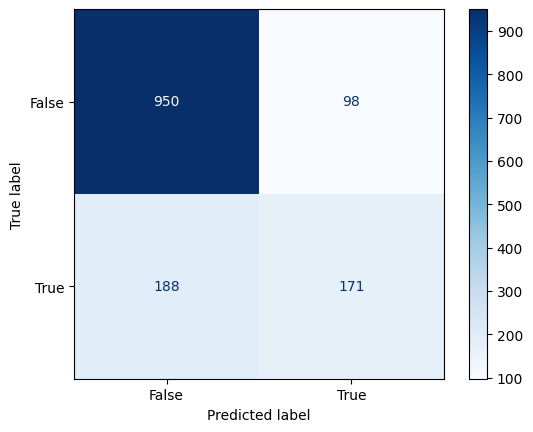

In [84]:
rc =RidgeClassifier()
model0=rc.fit(x_train, y_train)
print("train accuracy:",model0.score(x_train, y_train),"\n","test accuracy:",model0.score(x_test,y_test))
#auc roc
pred_prob0 = model0.decision_function((x_test))
auc_score0 = roc_auc_score(y_test, pred_prob0)
print("auc roc score :", auc_score0)

precision, recall,_= precision_recall_curve(y_test,pred_prob0)
auc_score0 = auc(recall, precision)
print("auc score from precision recall curve :", auc_score0)
'''The best model would be selected from the highest recall and precison values for the churn prediction. Hence these
   values are not calculated for other classifiers. predict function was used to predict the response for the test set.'''
rcpred = rc.predict(x_test)
print("\n")
print("classification report for ridge classifier")
print(classification_report(y_test,rcpred))
print("\n")
print("confusion matrix for ridge classifier")
ConfusionMatrixDisplay.from_estimator(rc, x_test, y_test,cmap="Blues")

train accuracy: 0.8062222222222222 
 test accuracy: 0.8031272210376688


classification report for logistic regression
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1048
        True       0.65      0.51      0.57       359

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



confusion matrix for logistic regression


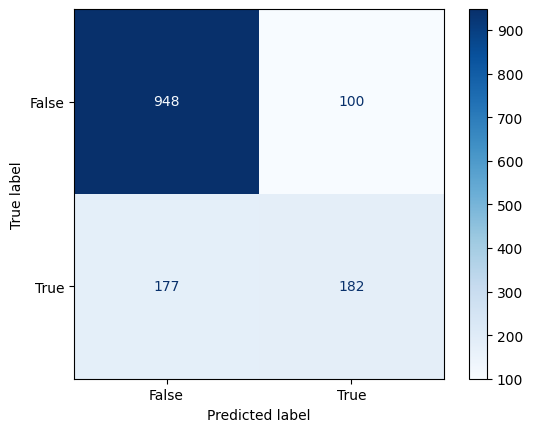

In [85]:
#logistic regression
lr = LogisticRegression(max_iter=2000,penalty='l2')
model1=lr.fit(x_train, y_train)
print("train accuracy:",model1.score(x_train, y_train),"\n","test accuracy:",model1.score(x_test,y_test))
lrpred = lr.predict(x_test)
print("\n")
print("classification report for logistic regression")
print(classification_report(y_test,lrpred))
print("\n")
print("confusion matrix for logistic regression")
ConfusionMatrixDisplay.from_estimator(lr, x_test, y_test,cmap="Blues")

C:\Users\C\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


train accuracy: 0.8055111111111111 
 test accuracy: 0.8017057569296375


classification report for support vector machines 
              precision    recall  f1-score   support

       False       0.84      0.91      0.87      1048
        True       0.65      0.49      0.56       359

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.79      0.80      0.79      1407



confusion matrix for support vector machines


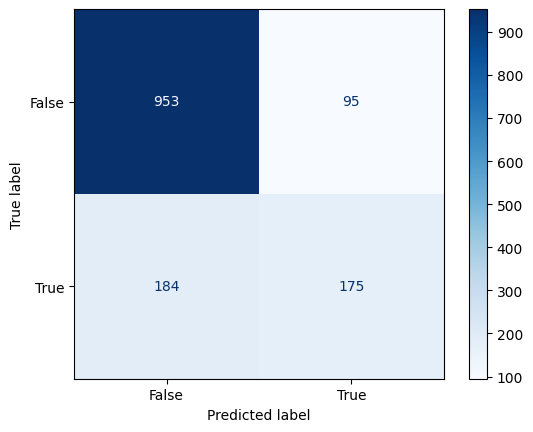

In [86]:
#support vector machines
svm =LinearSVC()
model2=svm.fit(x_train, y_train)
print("train accuracy:",model2.score(x_train, y_train),"\n","test accuracy:",model2.score(x_test,y_test))
svmpred = svm.predict(x_test)
print("\n")
print("classification report for support vector machines ")
print(classification_report(y_test,svmpred))
print("\n")
print("confusion matrix for support vector machines")
ConfusionMatrixDisplay.from_estimator(svm, x_test, y_test,cmap="Blues")

train accuracy: 0.9976888888888888 
 test accuracy: 0.7270788912579957


classification report for decision tree classifier
              precision    recall  f1-score   support

       False       0.82      0.81      0.82      1048
        True       0.47      0.48      0.47       359

    accuracy                           0.73      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.73      0.73      0.73      1407



confusion matrix for decision tree classifier


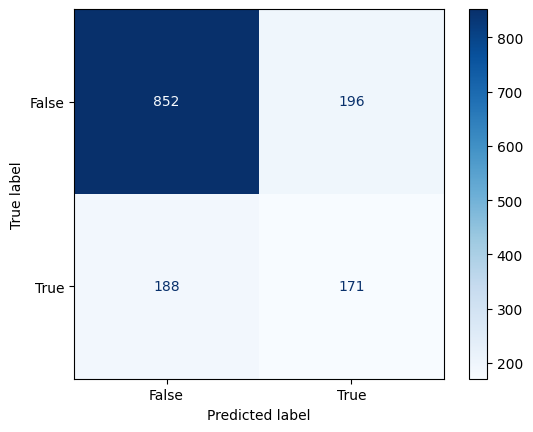

In [87]:
#decision tree classifier
dt=DecisionTreeClassifier()
model3=dt.fit(x_train, y_train)
print("train accuracy:",model3.score(x_train, y_train),"\n","test accuracy:",model3.score(x_test,y_test))

dtpred = dt.predict(x_test)
print("\n")
print("classification report for decision tree classifier")
print(classification_report(y_test,dtpred))
print("\n")
print("confusion matrix for decision tree classifier")
ConfusionMatrixDisplay.from_estimator(dt, x_test, y_test,cmap="Blues")

train accuracy: 0.9975111111111111 
 test accuracy: 0.7924662402274343


classification report for random forest classifier
              precision    recall  f1-score   support

       False       0.83      0.90      0.87      1048
        True       0.62      0.48      0.54       359

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



confusion matrix for random forest classifier


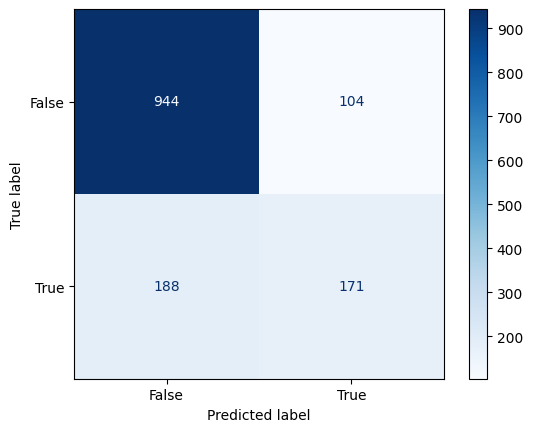

In [88]:
#random forest classifier
rf=RandomForestClassifier(random_state=1234)
model4=rf.fit(x_train, y_train)
print("train accuracy:",model4.score(x_train, y_train),"\n","test accuracy:",model4.score(x_test,y_test))

rfpred = rf.predict(x_test)
print("\n")
print("classification report for random forest classifier")
print(classification_report(y_test,rfpred))
print("\n")
print("confusion matrix for random forest classifier")
ConfusionMatrixDisplay.from_estimator(rf, x_test, y_test,cmap="Blues")

train accuracy: 0.8296888888888889 
 test accuracy: 0.8017057569296375


classification report for gradient boosting classifier
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1048
        True       0.64      0.52      0.57       359

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



confusion matrix for gradient boosting classifier


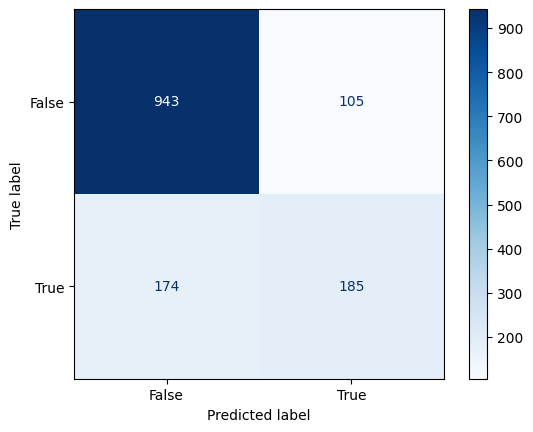

In [89]:
# gradient boost classifier 
gbm=GradientBoostingClassifier()
model5=gbm.fit(x_train, y_train)
print("train accuracy:",model5.score(x_train, y_train),"\n","test accuracy:",model5.score(x_test,y_test))

gbmpred = gbm.predict(x_test)
print("\n")
print("classification report for gradient boosting classifier")
print(classification_report(y_test,gbmpred))
print("\n")
print("confusion matrix for gradient boosting classifier")
ConfusionMatrixDisplay.from_estimator(gbm, x_test, y_test,cmap="Blues")

train accuracy: 0.8332444444444445 
 test accuracy: 0.759772565742715


classification report for KNN classifier
              precision    recall  f1-score   support

       False       0.84      0.84      0.84      1048
        True       0.53      0.52      0.52       359

    accuracy                           0.76      1407
   macro avg       0.68      0.68      0.68      1407
weighted avg       0.76      0.76      0.76      1407



confusion matrix for KNN classifier


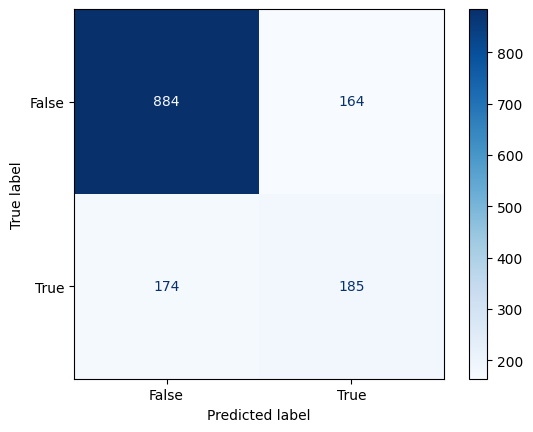

In [93]:
# KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

knn = KNeighborsClassifier(n_neighbors=5)

model_knn = knn.fit(x_train, y_train)

print("train accuracy:", model_knn.score(x_train, y_train), "\n",
      "test accuracy:", model_knn.score(x_test, y_test))

knnpred = knn.predict(x_test)

print("\n")
print("classification report for KNN classifier")
print(classification_report(y_test, knnpred))

print("\n")
print("confusion matrix for KNN classifier")
ConfusionMatrixDisplay.from_estimator(knn, x_test, y_test, cmap="Blues")

C:\Users\C\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


train accuracy: 0.8087111111111112 
 test accuracy: 0.7995735607675906


classification report for adaboost classifier
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1048
        True       0.63      0.52      0.57       359

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



confusion matrix for adaboost classifier


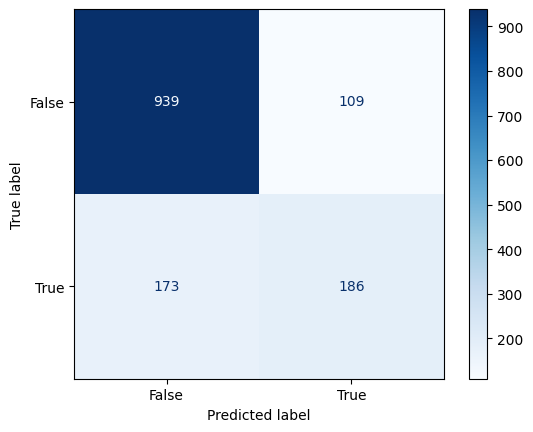

In [91]:
# adaboost classifier 
ada=AdaBoostClassifier()
model6=ada.fit(x_train, y_train)
print("train accuracy:",model6.score(x_train, y_train),"\n","test accuracy:",model6.score(x_test,y_test))

adapred = ada.predict(x_test)
print("\n")
print("classification report for adaboost classifier")
print(classification_report(y_test,adapred))
print("\n")
print("confusion matrix for adaboost classifier")
ConfusionMatrixDisplay.from_estimator(ada, x_test, y_test,cmap="Blues")

train accuracy: 0.9328 
 test accuracy: 0.7839374555792467


classification report for extreme gradient boosting classifier
              precision    recall  f1-score   support

       False       0.84      0.88      0.86      1048
        True       0.59      0.51      0.55       359

    accuracy                           0.78      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.78      0.78      0.78      1407



confusion matrix for extreme gradient boosting classifier


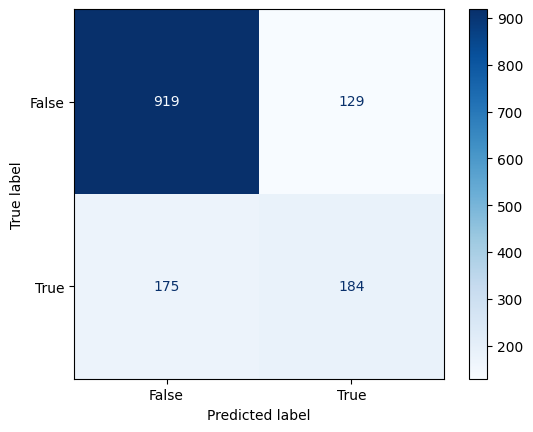

In [92]:
# extreme gradient boost classifier
xgb = XGBClassifier(random_state=1234)
model7=xgb.fit(x_train.values, y_train)
print("train accuracy:",model7.score(x_train.values, y_train),"\n","test accuracy:",model7.score(x_test.values,y_test))
xgbpred = xgb.predict(x_test.values)
print("\n")
print("classification report for extreme gradient boosting classifier")
print(classification_report(y_test,xgbpred))
print("\n")
print("confusion matrix for extreme gradient boosting classifier")
ConfusionMatrixDisplay.from_estimator(xgb, x_test.values, y_test,cmap="Blues")

In [73]:
!pip install plot_confusion_matrix


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\C\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.svm import LinearSVC

#libraries for model evaluation
from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc

train accuracy: 0.8055111111111111 
 test accuracy: 0.7967306325515281
auc roc score : 0.8320477790299604
auc score from precision recall curve : 0.6258465991380682


classification report for ridge classifier
              precision    recall  f1-score   support

       False       0.83      0.91      0.87      1048
        True       0.64      0.48      0.54       359

    accuracy                           0.80      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.80      0.79      1407



confusion matrix for ridge classifier


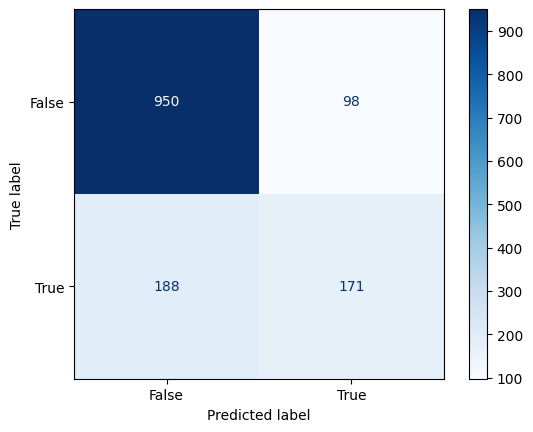

In [75]:
rc =RidgeClassifier()
model0=rc.fit(x_train, y_train)
print("train accuracy:",model0.score(x_train, y_train),"\n","test accuracy:",model0.score(x_test,y_test))
#auc roc
pred_prob0 = model0.decision_function((x_test))
auc_score0 = roc_auc_score(y_test, pred_prob0)
print("auc roc score :", auc_score0)

precision, recall,_= precision_recall_curve(y_test,pred_prob0)
auc_score0 = auc(recall, precision)
print("auc score from precision recall curve :", auc_score0)
'''The best model would be selected from the highest recall and precison values for the churn prediction. Hence these
   values are not calculated for other classifiers. predict function was used to predict the response for the test set.'''
rcpred = rc.predict(x_test)
print("\n")
print("classification report for ridge classifier")
print(classification_report(y_test,rcpred))
print("\n")
print("confusion matrix for ridge classifier")
ConfusionMatrixDisplay.from_estimator(rc, x_test, y_test,cmap="Blues")

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}

Train Accuracy: 0.8257777777777778
Test Accuracy: 0.7896233120113717

Classification Report:

              precision    recall  f1-score   support

       False       0.84      0.88      0.86      1048
        True       0.60      0.52      0.56       359

    accuracy                           0.79      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


F1 Score: 0.5595238095238095
ROC-AUC: 0.8031201492695996

Confusion Matrix:


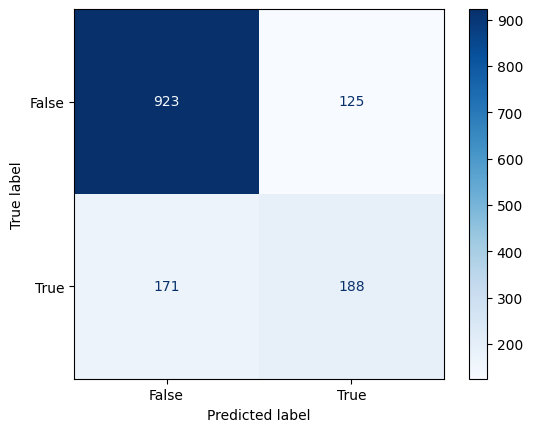

In [96]:
# ==============================
# KNN with RFE + GridSearchCV
# ==============================

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

# ------------------------------
# 1. Scaling (required for KNN)
# ------------------------------
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# ------------------------------
# 2. RFE (Feature Selection)
# ------------------------------
rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=10)

x_train_rfe = rfe.fit_transform(x_train_scaled, y_train)
x_test_rfe = rfe.transform(x_test_scaled)

# ------------------------------
# 3. KNN + GridSearchCV
# ------------------------------
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(knn, param_grid, cv=5, scoring='f1', n_jobs=-1)

grid.fit(x_train_rfe, y_train)

best_knn = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# ------------------------------
# 4. Evaluation
# ------------------------------
y_pred = best_knn.predict(x_test_rfe)
y_proba = best_knn.predict_proba(x_test_rfe)[:, 1]

print("\nTrain Accuracy:", best_knn.score(x_train_rfe, y_train))
print("Test Accuracy:", best_knn.score(x_test_rfe, y_test))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nF1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_estimator(best_knn, x_test_rfe, y_test, cmap="Blues")